# YOLO26 + VLM Hands-on: Make the Coordination Decisions

You will run the same video through three controlled experiments:

```text
YOLO-only -> VLM-only -> YOLO + asynchronous ROI VLM
```

Then you will change one supported parameter, compare evidence, and design how a future system should move from fixed polling to meaningful coordination.

**Submission:** one `decision.json`, one A/B comparison, and one six-part coordination answer.

## 1. Map the in-image models and verify both services

The Notebook may start in any directory. The first code cell creates `./models` as a symlink to the immutable model directory inside the image, discovers the current source tree or immutable seed, and creates `./output` for this run. It never downloads models in baked mode.

In [1]:
import importlib
import json
import os
import sys
from pathlib import Path


NOTEBOOK_DIR = Path.cwd().resolve()
BAKED_SEED = Path(os.environ.get(
    "ULTRALYTICS_WORKSHOP_SEED_DIR", "/opt/ultralytics-yolo26/seed"
)).resolve()
BAKED_MODELS = Path(os.environ.get(
    "ULTRALYTICS_BAKED_MODEL_DIR", "/opt/ultralytics-yolo26/models"
)).resolve()


def is_package_root(path: Path) -> bool:
    return (
        (path / "scripts/notebook_env.py").is_file()
        and (path / "src").is_dir()
        and (path / "data").is_dir()
    )


def find_package_root() -> Path:
    candidates = []
    for variable in ("ULTRALYTICS_YOLO26_ROOT", "OPENCV_AMD_END2END_ROOT"):
        if os.environ.get(variable):
            candidates.append(Path(os.environ[variable]).expanduser())
    candidates.extend([NOTEBOOK_DIR, *NOTEBOOK_DIR.parents])
    candidates.extend(Path(value) for value in sys.path if value)
    candidates.append(BAKED_SEED)

    visited = set()
    for origin in candidates:
        try:
            resolved = origin.resolve()
        except (OSError, RuntimeError):
            continue
        for candidate in (resolved, *resolved.parents):
            if candidate in visited:
                continue
            visited.add(candidate)
            if is_package_root(candidate):
                return candidate
    raise FileNotFoundError(
        "Cannot find the ultralytics_yolo26 sources from the current directory "
        f"({NOTEBOOK_DIR}) or immutable seed ({BAKED_SEED})."
    )


def map_baked_models(work_dir: Path, source_dir: Path) -> tuple[Path, str]:
    required = (
        "yolo26x.pt",
        "yolo26x.onnx",
        "Qwen3-VL-8B-Instruct-Q8_0.gguf",
        "mmproj-F16.gguf",
    )
    missing = [name for name in required if not (source_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(
            f"Baked model directory is incomplete: {source_dir}; missing={missing}"
        )

    alias = work_dir / "models"
    if alias.is_symlink():
        if alias.resolve() != source_dir:
            alias.unlink()
            alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    if alias.exists():
        if alias.resolve() == source_dir:
            return source_dir, "existing mapping"
        local_missing = [name for name in required if not (alias / name).is_file()]
        if local_missing:
            raise RuntimeError(
                f"Cannot map baked models: {alias} is an existing real path and "
                f"does not contain the release model set (missing={local_missing}). "
                "Remove that mount/directory or set ULTRALYTICS_YOLO26_MODEL_DIR "
                "to a complete model set."
            )
        return alias.resolve(), "existing model directory"

    try:
        alias.symlink_to(source_dir, target_is_directory=True)
        return alias.resolve(), "symlink"
    except OSError as error:
        print(
            f"[bootstrap] Cannot create {alias} -> {source_dir}: {error}. "
            "Using the immutable model directory directly."
        )
        return source_dir, "direct fallback"


ROOT = find_package_root()
MODEL_DIR, MODEL_MAPPING = map_baked_models(NOTEBOOK_DIR, BAKED_MODELS)
OUTPUT_DIR = NOTEBOOK_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["ULTRALYTICS_YOLO26_ROOT"] = str(ROOT)
os.environ["ULTRALYTICS_YOLO26_MODEL_DIR"] = str(MODEL_DIR)
os.environ["ULTRALYTICS_YOLO26_OUTPUT_DIR"] = str(OUTPUT_DIR)
os.environ["ULTRALYTICS_MIGRAPHX_CACHE_ROOT"] = str(
    MODEL_DIR / "ort-migraphx-cache"
)
os.environ.setdefault("HF_ENDPOINT", "https://hf-mirror.com")
for value in (str(ROOT), str(ROOT / "src")):
    if value not in sys.path:
        sys.path.insert(0, value)

from scripts import notebook_env as env
env = importlib.reload(env)
from scripts.model_setup import ensure_models, model_status
from scripts.notebook_helpers import frame_at, show_bgr, show_bgr_grid, video_info
from scripts.validate_runtime import validate

delivery_mode = (
    "baked/offline verification"
    if os.environ.get("ULTRALYTICS_WORKSHOP_BUNDLE") == "baked"
    else "development fallback download"
)
models = ensure_models(env.MODELS, progress=True)
runtime = validate(require_models=True, require_vlm=False)
print(json.dumps({
    "notebook_dir": str(NOTEBOOK_DIR),
    "source_root": str(ROOT),
    "model_source": str(BAKED_MODELS),
    "model_alias": str(NOTEBOOK_DIR / "models"),
    "model_mapping": MODEL_MAPPING,
    "model_delivery": delivery_mode,
    **runtime,
}, indent=2))
models

from scripts.model_setup import wait_for_llamacpp

vlm_service = wait_for_llamacpp(timeout=60, progress=False)
print(json.dumps({
    "model_mapping": MODEL_MAPPING,
    "models": str(env.MODELS),
    "output": str(env.OUTPUT),
    "vlm_model": vlm_service["data"][0]["id"],
}, indent=2))

[models] yolo26x.pt: verified baked model
[models] yolo26x.onnx: verified baked model
[models] Qwen3-VL-8B-Instruct-Q8_0.gguf: verified baked model
[models] mmproj-F16.gguf: verified baked model
[models] MIGraphX cache: /opt/ultralytics-yolo26/models/ort-migraphx-cache (verified baked gfx1100 cache)


WARNING ⚠️ user config directory '/tmp/ultralytics/Ultralytics' is not writable, using '/tmp/Ultralytics'. Set YOLO_CONFIG_DIR to override.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/tmp/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


{
  "notebook_dir": "/tmp/hands-on-run",
  "source_root": "/job/source",
  "model_source": "/opt/ultralytics-yolo26/models",
  "model_alias": "/tmp/hands-on-run/models",
  "model_mapping": "symlink",
  "model_delivery": "baked/offline verification",
  "root": "/job/source",
  "src": "/job/source/src",
  "data": "/job/source/data",
  "models": "/opt/ultralytics-yolo26/models",
  "output": "/tmp/hands-on-run/output",
  "opencv_install": "/opt/opencv5",
  "llamacpp": "http://yolo26_llama_slot3_validation:8199/v1",
  "python": "/opt/venv/bin/python3",
  "opencv": "5.1.0-dev",
  "opencv_hip_devices": 1,
  "torch": "2.9.1+gitff65f5b",
  "torch_gpu": "AMD Radeon PRO W7900D",
  "gpu_arch": "gfx1100",
  "ultralytics": "8.4.75",
  "onnxruntime": "1.24.2",
  "onnxruntime_providers": [
    "MIGraphXExecutionProvider",
    "CPUExecutionProvider"
  ],
  "migraphx_cache": "/opt/ultralytics-yolo26/models/ort-migraphx-cache"
}
{
  "model_mapping": "symlink",
  "models": "/opt/ultralytics-yolo26/models"

## 2. Inspect the video and predict the top ROIs

Before running the VLM, inspect one YOLO frame. Write down which detections you expect a confidence-ranked top-3 policy to select, and whether those are necessarily the most useful objects for scene understanding.

[detector] Loading YOLO26x ONNX through Ultralytics...
[detector] MIGraphX cache identity: 735f1583e99dfeb733da


Loading /opt/ultralytics-yolo26/models/yolo26x.onnx for ONNX Runtime inference...


Using ONNX Runtime 1.24.2 with MIGraphXExecutionProvider


MIGraphX FP16 provider option is enabled; model input remains FP32.


2026-09-09 11:27:03.203136203 [W:onnxruntime:Default, migraphx_execution_provider.cc:167 MIGraphXExecutionProvider] [MIGraphX EP] MIGraphX ENV Override Variables Set:


[detector] Ultralytics ONNX + MIGraphX EP (FP16, GPU I/O binding) ready; output=(1, 300, 6)


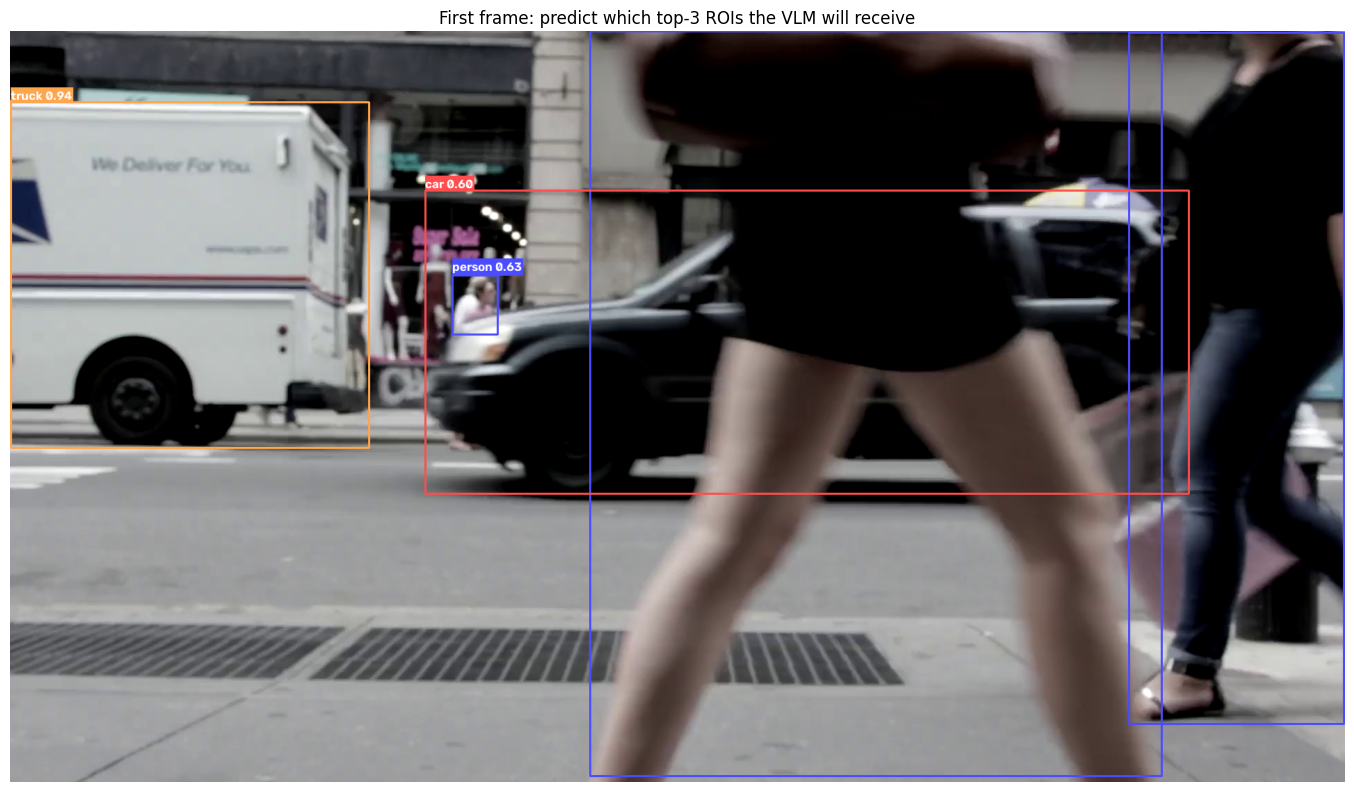

,rank,class,confidence,bbox
0,1,person,0.9580,"[834.0, 0.8, 1656.0, 1071.0]"
1,2,truck,0.9438,"[1.4, 102.4, 516.8, 599.2]"
2,3,person,0.9282,"[1609.5, 2.2, 1918.5, 996.8]"


{
  "source": {
    "width": 1920,
    "height": 1080,
    "fps": 25.0,
    "frames": 393,
    "duration_seconds": 15.72
  },
  "selected_roi": "/tmp/hands-on-run/output/hands_on/selected_top1_roi.jpg"
}


In [2]:
import gc
import time

import cv2
import pandas as pd
import torch
from IPython.display import display

from detector import UltralyticsYOLODetector
from postprocess import draw_detections
from preprocess import preprocess_frame_cpu

hands_on_dir = env.OUTPUT / "hands_on"
hands_on_dir.mkdir(parents=True, exist_ok=True)
source_info = video_info(env.SOURCE_VIDEO)
first_frame = frame_at(env.SOURCE_VIDEO, 0.0)
detector = UltralyticsYOLODetector(str(env.YOLO_ONNX), device_id=0)
blob, scale, pad_w, pad_h = preprocess_frame_cpu(first_frame)
detections = detector.detect_and_parse(blob, scale, pad_w, pad_h, first_frame.shape)
ranked_detections = sorted(detections, key=lambda item: item[4], reverse=True)
top_detections = ranked_detections[:3]

annotated = first_frame.copy()
draw_detections(annotated, detections, names=detector.names)
show_bgr(annotated, "First frame: predict which top-3 ROIs the VLM will receive")
display(pd.DataFrame(
    [
        {
            "rank": rank,
            "class": detector.names[int(det[5])],
            "confidence": round(float(det[4]), 4),
            "bbox": [round(float(value), 1) for value in det[:4]],
        }
        for rank, det in enumerate(top_detections, 1)
    ]
))

x1, y1, x2, y2 = [int(value) for value in top_detections[0][:4]]
selected_roi = first_frame[max(0, y1):max(y1 + 1, y2), max(0, x1):max(x1 + 1, x2)].copy()
selected_roi_path = hands_on_dir / "selected_top1_roi.jpg"
assert selected_roi.size and cv2.imwrite(str(selected_roi_path), selected_roi)
print(json.dumps({"source": source_info, "selected_roi": str(selected_roi_path)}, indent=2))

del detector
gc.collect()
torch.cuda.empty_cache()

## 3. Establish a fair YOLO-only baseline

This baseline deliberately uses the same CPU overlay and VA-API writer boundary as the async ROI run. It is not the faster `vaapi-direct` release benchmark. Keeping the non-VLM stages equal makes the A/B comparison meaningful.

In [3]:
from scripts.async_roi_workflow import run_experiment

RUN_HANDS_ON = os.environ.get("RUN_HANDS_ON", "0") == "1"
HANDS_ON_FRAMES = int(os.environ.get("HANDS_ON_FRAMES", "120"))
yolo_only = run_experiment(
    output_dir=hands_on_dir,
    mode="yolo-only",
    max_frames=HANDS_ON_FRAMES,
    force=RUN_HANDS_ON,
)
print(json.dumps({
    "frames": yolo_only["metrics"]["frames"],
    "fps": yolo_only["metrics"]["fps"],
    "detection_mean_ms": yolo_only["metrics"]["detection_mean_ms"],
    "frame_d2h_mean_ms": yolo_only["metrics"]["frame_d2h_mean_ms"],
    "video": yolo_only["video"],
}, indent=2))

{
  "frames": 120,
  "fps": 48.542,
  "detection_mean_ms": 10.884,
  "frame_d2h_mean_ms": 2.249,
  "video": {
    "width": 1920,
    "height": 1080,
    "codec": "h264",
    "profile": "High",
    "pixel_format": "yuv420p",
    "frame_rate": "25/1",
    "duration_seconds": 4.8,
    "container_samples": 120,
    "packets": 120,
    "decoded_frames": 120
  }
}


## 4. Measure one VLM request before adding concurrency

The selected ROI is JPEG-encoded and sent to the persistent llama.cpp service. This client wall time includes JPEG, Base64, HTTP, vision encoding, prompt evaluation, and generation. Predict the latency before running the cell.

[llama.cpp] auto-resolved model: /models/Qwen3-VL-8B-Instruct-Q8_0.gguf


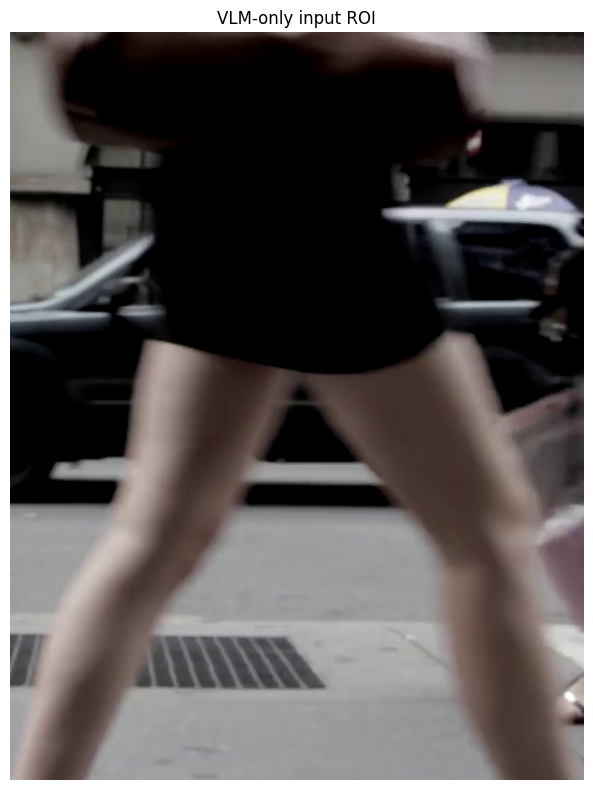

{
  "roi": "/tmp/hands-on-run/output/hands_on/selected_top1_roi.jpg",
  "latency_ms": 1700.828,
  "output": "A person in black shorts walks past a parked car on a city sidewalk, captured in motion blur."
}


In [4]:
from vlm_client import LlamaCppVLMClient

vlm_client = LlamaCppVLMClient(base_url=env.LLAMACPP_BASE_URL)
assert vlm_client.health_check()
vlm_prompt = "Describe only the visible object and its immediate context in one concise sentence."
started = time.perf_counter()
vlm_only_output = vlm_client.describe_roi(selected_roi, vlm_prompt)
vlm_only_latency_ms = (time.perf_counter() - started) * 1000
vlm_only = {
    "roi": str(selected_roi_path),
    "latency_ms": round(vlm_only_latency_ms, 3),
    "output": vlm_only_output,
}
(hands_on_dir / "vlm_only.json").write_text(
    json.dumps(vlm_only, indent=2) + "\n", encoding="utf-8"
)
show_bgr(selected_roi, "VLM-only input ROI")
print(json.dumps(vlm_only, indent=2))

## 5. Decision point: choose one executable configuration

Change only one variable from the baseline. The current implementation supports `interval` and `top_k` directly. `busy_policy=skip` and `transport=jpeg_http` are fixed implementation facts, not pretend switches.

In [5]:
from scripts.async_roi_workflow import pipeline_command

# Edit one supported value, then explain your prediction before running.
DECISION = {
    "vlm_interval_frames": int(os.environ.get("HANDS_ON_INTERVAL", "30")),
    "vlm_top_k": int(os.environ.get("HANDS_ON_TOP_K", "3")),
    "busy_policy": "skip",
    "transport": "jpeg_http",
    "gpu_placement": os.environ.get("HANDS_ON_GPU_PLACEMENT", "single_gpu"),
    "max_frames": HANDS_ON_FRAMES,
}
assert DECISION["vlm_interval_frames"] in {15, 30, 60}
assert DECISION["vlm_top_k"] in {1, 3}
assert DECISION["busy_policy"] == "skip"
assert DECISION["transport"] == "jpeg_http"
assert DECISION["gpu_placement"] in {"single_gpu", "split_gpu"}
(hands_on_dir / "decision.json").write_text(
    json.dumps(DECISION, indent=2) + "\n", encoding="utf-8"
)
preview_command, _ = pipeline_command(
    output_dir=hands_on_dir,
    mode="async-roi",
    max_frames=DECISION["max_frames"],
    interval=DECISION["vlm_interval_frames"],
    top_k=DECISION["vlm_top_k"],
)
print(json.dumps(DECISION, indent=2))
print("Command:", " ".join(preview_command))

{
  "vlm_interval_frames": 30,
  "vlm_top_k": 3,
  "busy_policy": "skip",
  "transport": "jpeg_http",
  "gpu_placement": "single_gpu",
  "max_frames": 120
}
Command: /opt/venv/bin/python3 /job/source/src/pipeline.py --input /job/source/data/sidewalk.mp4 --output /tmp/hands-on-run/output/hands_on/async_roi.mp4 --video-decode rocdecode --video-encode vaapi --gpu-direct-encode off --metrics-json /tmp/hands-on-run/output/hands_on/async_roi_metrics.json --max-frames 120 --vlm-url http://yolo26_llama_slot3_validation:8199/v1 --vlm-interval 30 --vlm-top-k 3 --vlm-drain-timeout 15.0


## 6. Run YOLO with asynchronous ROI VLM

YOLO keeps processing frames while one accepted VLM batch runs in a background thread. At each trigger opportunity the client either accepts one top-K batch or records `skipped_busy`. Async removes software waiting; it does not remove shared-GPU contention.

In [6]:
async_roi = run_experiment(
    output_dir=hands_on_dir,
    mode="async-roi",
    max_frames=DECISION["max_frames"],
    interval=DECISION["vlm_interval_frames"],
    top_k=DECISION["vlm_top_k"],
    drain_timeout=15.0,
    force=RUN_HANDS_ON,
)
print(json.dumps({
    "frames": async_roi["metrics"]["frames"],
    "fps": async_roi["metrics"]["fps"],
    "detection_mean_ms": async_roi["metrics"]["detection_mean_ms"],
    "detection_vlm_idle": async_roi["metrics"]["detection_vlm_idle"],
    "detection_vlm_active": async_roi["metrics"]["detection_vlm_active"],
    "trigger_opportunities": async_roi["metrics"]["trigger_opportunities"],
    "trigger_with_detections": async_roi["metrics"]["trigger_with_detections"],
    "vlm": async_roi["metrics"]["vlm"],
}, indent=2))

{
  "frames": 120,
  "fps": 41.349,
  "detection_mean_ms": 19.579,
  "detection_vlm_idle": {
    "count": 23,
    "p50_ms": 10.671,
    "p95_ms": 14.751
  },
  "detection_vlm_active": {
    "count": 97,
    "p50_ms": 20.733,
    "p95_ms": 33.942
  },
  "trigger_opportunities": 5,
  "trigger_with_detections": 5,
  "vlm": {
    "submitted_batches": 2,
    "skipped_busy": 3,
    "submitted_rois": 6,
    "completed_batches": 2,
    "completed_rois": 6,
    "failed_rois": 0,
    "batch_latency_p50_ms": 3295.084,
    "batch_latency_p95_ms": 4318.651,
    "last_latency_ms": 4318.651,
    "active": false
  }
}


## 7. Read the A/B speed ledger

Do not select a configuration only because it has the largest FPS. Check frame integrity, detection latency during VLM activity, skipped batches, actual completed ROIs, and semantic freshness.

In [7]:
from scripts.async_roi_workflow import comparison

comparison_record = comparison(yolo_only, async_roi)
comparison_path = hands_on_dir / "comparison.json"
comparison_path.write_text(
    json.dumps(comparison_record, indent=2) + "\n", encoding="utf-8"
)
display(pd.DataFrame([
    {
        "mode": "YOLO-only",
        "frames": yolo_only["metrics"]["frames"],
        "fps": yolo_only["metrics"]["fps"],
        "detection_ms": yolo_only["metrics"]["detection_mean_ms"],
        "submitted_batches": 0,
        "skipped_busy": 0,
        "completed_rois": 0,
    },
    {
        "mode": "YOLO + async ROI VLM",
        "frames": async_roi["metrics"]["frames"],
        "fps": async_roi["metrics"]["fps"],
        "detection_ms": async_roi["metrics"]["detection_mean_ms"],
        "submitted_batches": async_roi["metrics"]["vlm"]["submitted_batches"],
        "skipped_busy": async_roi["metrics"]["vlm"]["skipped_busy"],
        "completed_rois": async_roi["metrics"]["vlm"]["completed_rois"],
    },
]))
print(json.dumps(comparison_record, indent=2))

,mode,frames,fps,detection_ms,submitted_batches,skipped_busy,completed_rois
0,YOLO-only,120,48.542,10.884,0,0,0
1,YOLO + async ROI VLM,120,41.349,19.579,2,3,6


{
  "frames": 120,
  "yolo_only_fps": 48.542,
  "parallel_fps": 41.349,
  "fps_retained_percent": 85.2,
  "yolo_only_detection_ms": 10.884,
  "parallel_detection_ms": 19.579,
  "parallel_detection_idle": {
    "count": 23,
    "p50_ms": 10.671,
    "p95_ms": 14.751
  },
  "parallel_detection_active": {
    "count": 97,
    "p50_ms": 20.733,
    "p95_ms": 33.942
  },
  "trigger_opportunities": 5,
  "trigger_with_detections": 5,
  "vlm_submitted_batches": 2,
  "vlm_skipped_busy": 3,
  "vlm_submitted_rois": 6,
  "vlm_completed_batches": 2,
  "vlm_completed_rois": 6,
  "vlm_failed_rois": 0,
  "vlm_batch_latency_p50_ms": 3295.084,
  "vlm_batch_latency_p95_ms": 4318.651,
  "vlm_last_latency_ms": 4318.651,
  "vlm_active": false
}


## 8. Design challenge: turn polling into purposeful coordination

The current system polls every N frames and selects confidence-ranked ROIs. Design the next version without implementing it today. Your answer must specify Trigger, Evidence, Output, Backpressure, Failure, and Metrics.

In [8]:
# Edit these six answers. Keep outputs constrained and failures explicit.
DESIGN_ANSWER = {
    "trigger": os.environ.get(
        "HANDS_ON_TRIGGER",
        "Create a candidate when a stable track enters a configured interaction zone.",
    ),
    "evidence": "Send before/trigger/after full-scene frames, subject ROI, and track metadata.",
    "output": "Return one allowlisted event label, visible facts, and uncertainty as JSON.",
    "backpressure": "Keep one active request and one latest candidate; replace stale pending work.",
    "failure": "Keep deterministic YOLO/track facts and mark semantic context unavailable.",
    "metrics": "Measure event recall, duplicate suppression, queue delay, VLM latency, and YOLO active-window P95.",
}
required_answer_fields = {"trigger", "evidence", "output", "backpressure", "failure", "metrics"}
assert set(DESIGN_ANSWER) == required_answer_fields
assert all(str(value).strip() for value in DESIGN_ANSWER.values())
(hands_on_dir / "design_answer.json").write_text(
    json.dumps(DESIGN_ANSWER, indent=2) + "\n", encoding="utf-8"
)
print(json.dumps(DESIGN_ANSWER, indent=2))

{
  "trigger": "Create a candidate when a stable track enters a configured interaction zone.",
  "evidence": "Send before/trigger/after full-scene frames, subject ROI, and track metadata.",
  "output": "Return one allowlisted event label, visible facts, and uncertainty as JSON.",
  "backpressure": "Keep one active request and one latest candidate; replace stale pending work.",
  "failure": "Keep deterministic YOLO/track facts and mark semantic context unavailable.",
  "metrics": "Measure event recall, duplicate suppression, queue delay, VLM latency, and YOLO active-window P95."
}


## 9. Takeaways

1. Async removes host-side waiting; it does not remove GPU contention.
2. `interval` controls trigger opportunities, `top_k` controls batch width, and `--parallel 3` controls server capacity.
3. Theoretical triggers are not submitted batches; submitted batches are not completed ROIs.
4. Shorter intervals improve freshness but increase busy skips and contention.
5. Fixed polling answers *how to run concurrently*; tracking and events answer *when a VLM call is worth paying for*.